# Task 3 — Marketing Funnel & Conversion Performance Analysis
**Future Interns | Data Science & Analytics Track | FUTURE_DS_03**

**Goal:** Analyze marketing funnel data to identify conversion drop-offs, channel performance, and opportunities to improve lead-to-customer conversion.

**Dataset:** `data/raw_funnel_data.csv` — weekly funnel volumes (Visitors → Leads → MQLs → SQLs → Customers) by acquisition channel for 2025, along with weekly ad spend.

**Tools used:** Python (pandas, matplotlib)

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('data/raw_funnel_data.csv', parse_dates=['WeekStart'])
print(df.shape)
df.head()

(312, 8)


,WeekStart,Channel,Visitors,Leads,MQLs,SQLs,Customers,AdSpend
0,2025-04-14,Google Ads,3477,498,256,105,29,64733.31
1,2025-06-09,Google Ads,4591,667,364,165,54,76120.79
2,2025-06-16,Organic Search,2837,284,158,80,31,0.00
3,2025-03-03,Organic Search,1780,181,98,52,15,0.00
4,2025-11-17,Facebook/Instagram Ads,4160,499,199,58,11,45006.95


## 2. Data Cleaning

The `Channel` column has an inconsistent variant of "Facebook/Instagram Ads" (extra spaces, different slash spacing) that needs to be standardised, otherwise it fragments the channel-level totals.

In [2]:
print(df['Channel'].unique())

<StringArray>
[               'Google Ads',            'Organic Search',
    'Facebook/Instagram Ads',                  'Referral',
              'Direct/Other',           'Email Marketing',
 'Facebook / Instagram Ads ']
Length: 7, dtype: str


In [3]:
df_clean = df.copy()
df_clean['Channel'] = df_clean['Channel'].str.strip()
df_clean['Channel'] = df_clean['Channel'].replace({'Facebook / Instagram Ads': 'Facebook/Instagram Ads'})
print(df_clean['Channel'].unique())

<StringArray>
[            'Google Ads',         'Organic Search', 'Facebook/Instagram Ads',
               'Referral',           'Direct/Other',        'Email Marketing']
Length: 6, dtype: str


## 3. Overall Funnel (Full Year)

In [4]:
funnel_totals = df_clean[['Visitors', 'Leads', 'MQLs', 'SQLs', 'Customers']].sum()
funnel_totals

Visitors     654357
Leads         99246
MQLs          56814
SQLs          25133
Customers      8972
dtype: int64

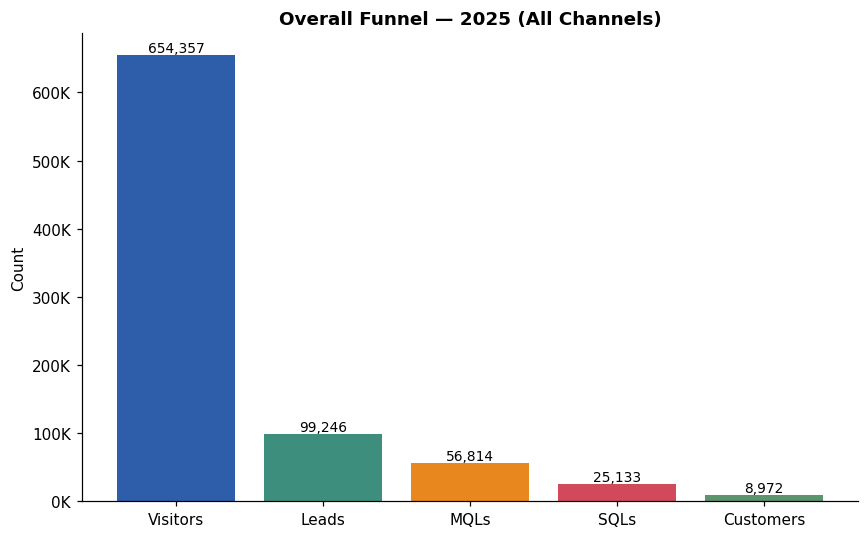

Visitors -> Leads: 15.2% conversion
Leads -> MQLs: 57.2% conversion
MQLs -> SQLs: 44.2% conversion
SQLs -> Customers: 35.7% conversion

Overall Visitor -> Customer conversion: 1.37%


In [5]:
stages = funnel_totals.index.tolist()
values = funnel_totals.values

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(stages, values, color=['#2E5EAA', '#3E8E7E', '#E8871E', '#D1495B', '#5C946E'])
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:,.0f}', ha='center', va='bottom', fontsize=9)
ax.set_title('Overall Funnel — 2025 (All Channels)', fontweight='bold')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
plt.tight_layout()
plt.savefig('overall_funnel.png', bbox_inches='tight')
plt.show()

for i in range(1, len(stages)):
    rate = values[i] / values[i-1] * 100
    print(f"{stages[i-1]} -> {stages[i]}: {rate:.1f}% conversion")

overall_conv = values[-1] / values[0] * 100
print(f"\nOverall Visitor -> Customer conversion: {overall_conv:.2f}%")

**Observation:** The biggest single drop-off is Visitors → Leads — that's expected for any top-of-funnel stage, but it's also the stage with the most room for a landing-page/CRO improvement to pay off, since even a small percentage-point gain here compounds through every later stage.

## 4. Conversion Rate by Channel

In [6]:
channel_summary = df_clean.groupby('Channel')[['Visitors', 'Leads', 'MQLs', 'SQLs', 'Customers', 'AdSpend']].sum()
channel_summary['Visitor_to_Lead%'] = (channel_summary['Leads'] / channel_summary['Visitors'] * 100).round(2)
channel_summary['Lead_to_Customer%'] = (channel_summary['Customers'] / channel_summary['Leads'] * 100).round(2)
channel_summary['Overall_Conv%'] = (channel_summary['Customers'] / channel_summary['Visitors'] * 100).round(2)
channel_summary['CAC'] = (channel_summary['AdSpend'] / channel_summary['Customers'].replace(0, np.nan)).round(0)
channel_summary.sort_values('Overall_Conv%', ascending=False)

,Visitors,Leads,MQLs,SQLs,Customers,AdSpend,Visitor_to_Lead%,Lead_to_Customer%,Overall_Conv%,CAC
Channel,,,,,,,,,,
Referral,52692,14637,10390,6077,3018,157559.37,27.78,20.62,5.73,52.0
Email Marketing,63816,14170,9312,4479,1725,125918.24,22.20,12.17,2.70,73.0
Google Ads,195680,30681,16788,6736,2033,3548073.85,15.68,6.63,1.04,1745.0
Organic Search,130060,13104,7971,3714,1276,0.00,10.08,9.74,0.98,0.0
Direct/Other,45809,6434,3141,1130,291,45976.93,14.05,4.52,0.64,158.0
Facebook/Instagram Ads,166300,20220,9212,2997,629,1989136.79,12.16,3.11,0.38,3162.0


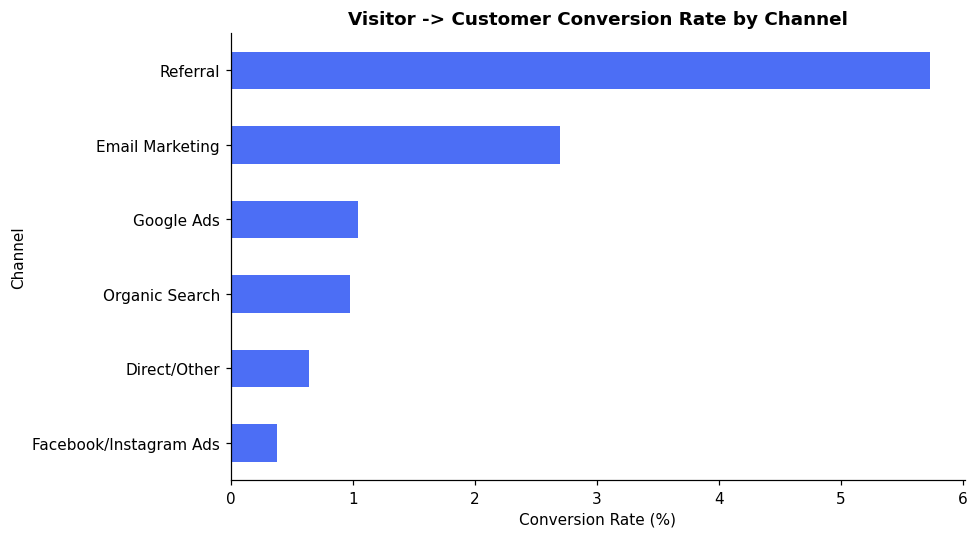

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
channel_summary['Overall_Conv%'].sort_values().plot(kind='barh', ax=ax, color='#4C6EF5')
ax.set_title('Visitor -> Customer Conversion Rate by Channel', fontweight='bold')
ax.set_xlabel('Conversion Rate (%)')
plt.tight_layout()
plt.savefig('conversion_by_channel.png', bbox_inches='tight')
plt.show()

**Observation:** Referral and Email convert far better than paid channels end-to-end, even though they bring in fewer total visitors. Google Ads and Facebook/Instagram Ads bring the most volume but convert at a noticeably lower rate — meaning the current spend mix is optimized for reach, not efficiency.

## 5. Cost Efficiency — Customer Acquisition Cost (CAC) by Channel

In [8]:
cac_df = channel_summary[channel_summary['AdSpend'] > 0][['AdSpend', 'Customers', 'CAC']].sort_values('CAC')
cac_df

,AdSpend,Customers,CAC
Channel,,,
Referral,157559.37,3018,52.0
Email Marketing,125918.24,1725,73.0
Direct/Other,45976.93,291,158.0
Google Ads,3548073.85,2033,1745.0
Facebook/Instagram Ads,1989136.79,629,3162.0


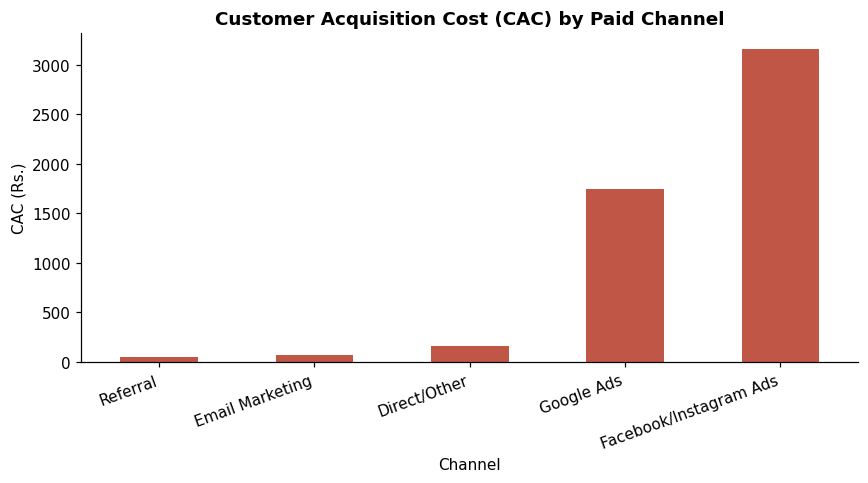

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
cac_df['CAC'].plot(kind='bar', ax=ax, color='#C05746')
ax.set_title('Customer Acquisition Cost (CAC) by Paid Channel', fontweight='bold')
ax.set_ylabel('CAC (Rs.)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('cac_by_channel.png', bbox_inches='tight')
plt.show()

**Observation:** Facebook/Instagram Ads has the highest CAC among paid channels despite decent volume — combined with its below-average conversion rate, it's the weakest paid channel on a pure efficiency basis, even if it's useful for top-of-funnel awareness.

## 6. Funnel Trend Over the Year

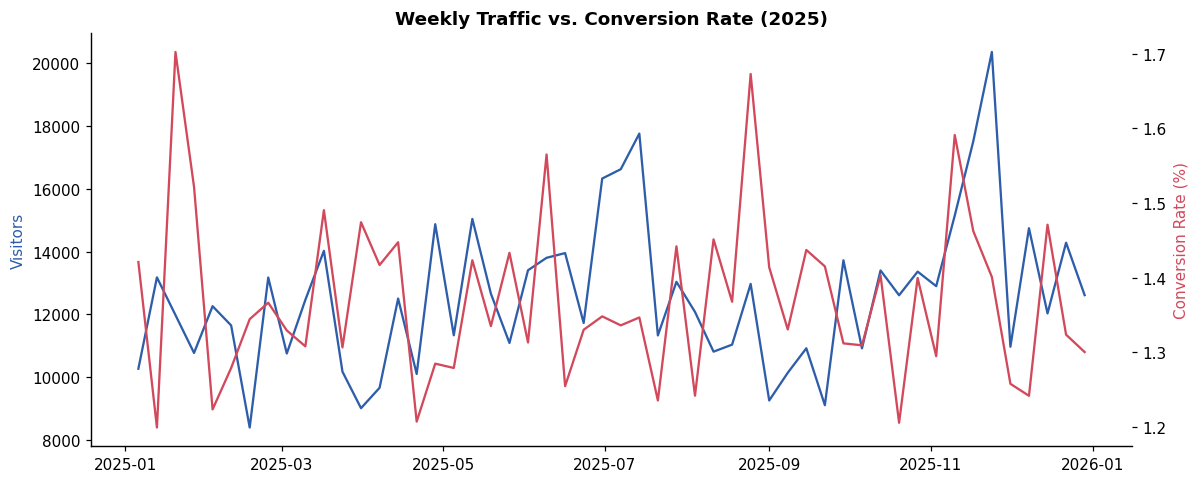

In [10]:
weekly_totals = df_clean.groupby('WeekStart')[['Visitors', 'Customers']].sum()
weekly_totals['ConversionRate%'] = (weekly_totals['Customers'] / weekly_totals['Visitors'] * 100)

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax2 = ax1.twinx()

ax1.plot(weekly_totals.index, weekly_totals['Visitors'], color='#2E5EAA', label='Visitors')
ax2.plot(weekly_totals.index, weekly_totals['ConversionRate%'], color='#D1495B', label='Conversion Rate %')

ax1.set_ylabel('Visitors', color='#2E5EAA')
ax2.set_ylabel('Conversion Rate (%)', color='#D1495B')
ax1.set_title('Weekly Traffic vs. Conversion Rate (2025)', fontweight='bold')
plt.tight_layout()
plt.savefig('weekly_trend.png', bbox_inches='tight')
plt.show()

**Observation:** The November traffic spike (festive season) doesn't come with a proportional lift in conversion rate — in fact it dips slightly, which is typical of paid-heavy, promo-driven traffic that's lower intent. Worth ensuring lead nurturing capacity scales with the traffic spike so leads generated in November aren't wasted.

## 7. Key Insights

1. **Visitor → Lead is the single biggest drop-off point** in the funnel — improving landing page conversion here has the largest compounding effect on total customers.
2. **Referral and Email are the most efficient channels end-to-end**, both on conversion rate and (for Email) on cost, despite bringing in a fraction of the traffic that paid search/social does.
3. **Facebook/Instagram Ads has the highest CAC and a below-average conversion rate** among paid channels — it's currently the least efficient dollar-for-dollar spend.
4. **Traffic and conversion quality move in opposite directions during the festive spike** — more visitors in November, but a slightly lower conversion rate, suggesting an influx of lower-intent, promo-driven traffic.
5. **Organic Search converts nearly as well as Referral** at zero incremental spend, which makes it an underused lever relative to its current share of total traffic.

## 8. Recommendations

- Run **A/B tests on the top-of-funnel landing pages** feeding the Visitor→Lead step — even a 2-3 point improvement here compounds through every later stage.
- **Shift incremental budget from Facebook/Instagram Ads toward Google Ads and Email**, based on their better conversion-to-spend ratio; keep Facebook/Instagram for brand awareness only, not lead-gen KPIs.
- Build a **referral incentive program** to grow this channel intentionally — it already converts best, so scaling it (even modestly) should be high-ROI.
- Invest more in **SEO/organic content** given its strong conversion rate at effectively zero acquisition cost.
- **Scale up lead nurturing/sales capacity ahead of the November traffic spike** so the extra volume doesn't go to waste on leads that aren't followed up promptly.